In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

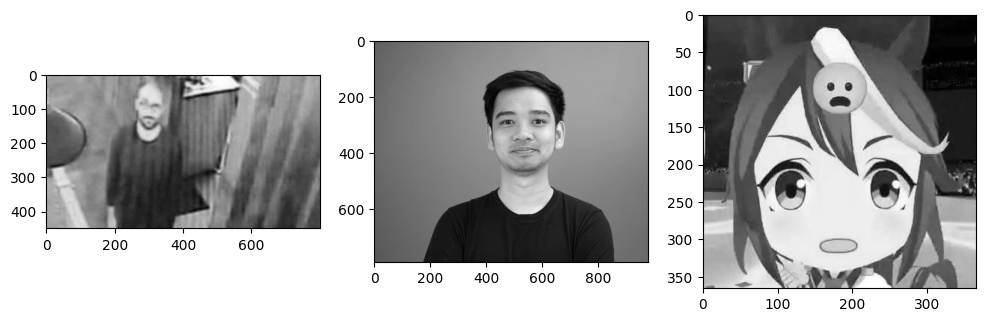

In [4]:
backup = cv2.imread("backup.jpg", cv2.IMREAD_GRAYSCALE)
david = cv2.imread("david.jpg", cv2.IMREAD_GRAYSCALE)
hachimi = cv2.imread("hachimi.jpeg", cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(12,8))
plt.subplot(1,3,1)
plt.imshow(backup, cmap='gray')
plt.subplot(1,3,2)
plt.imshow(david, cmap='gray')
plt.subplot(1,3,3)
plt.imshow(hachimi, cmap='gray')

In [73]:
def filter_citra(img, size, mode):
    # dimensi gambar / image dimensions
    height, width = img.shape
    # ukuran padding / padding size
    pad = size // 2
    # tambah padding tepi / add edge padding
    padded = np.pad(img, pad, mode='edge')
    # kanvas hasil / output canvas
    canvas = np.zeros_like(img, dtype=np.uint8)
    match mode:
        case 'mean':
            area = size * size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    total_sum = 0
                    for row in region:
                        for pixel in row:
                            total_sum += int(pixel)
                    
                    canvas[i, j] = total_sum // area

        case 'median':
            # filter median / median filter
            for i in range(height):
                for j in range(width):
                    # area kernel / kernel region
                    region = padded[i:i+size, j:j+size]
                    # rumus median manual / manual median formula
                    values = []
                    for row in region:
                        for val in row:
                            values.append(val)
                    # urutkan manual / manual sort (bubble sort)
                    n = len(values)
                    for a in range(n):
                        for b in range(0, n - a - 1):
                            if values[b] > values[b + 1]:
                                values[b], values[b + 1] = values[b + 1], values[b]
                    # ambil nilai tengah / get middle value
                    mid = n // 2
                    if n % 2 == 0:
                        canvas[i, j] = (values[mid - 1] + values[mid]) // 2
                    else:
                        canvas[i, j] = values[mid]

        case 'modus':
            # filter modus / mode filter
            for i in range(height):
                for j in range(width):
                    # area kernel / kernel region
                    region = padded[i:i+size, j:j+size]
                    # ratakan array / flatten array
                    values = region.ravel()
                    # hitung kemunculan / count occurrences
                    count = {}
                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1
                    # cari nilai terbanyak / find mode value
                    max_count = 0
                    mode_val = 0
                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val
                    # simpan hasil / save result
                    canvas[i, j] = mode_val
    # kembalikan gambar / return image
    return canvas

In [16]:
def convolution(img, kernel):
    # Ukuran kernel
    size = kernel.shape[0]
    
    # Ukuran padding
    pad_size = size // 2
    
    # Tambah padding nol (constant)
    padded = np.pad(img, pad_size, mode='constant')
    
    # Kanvas hasil (gunakan float32 untuk menampung nilai negatif/desimal)
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape
    
    for i in range(height):
        for j in range(width):
            # Area kernel
            region = padded[i:i+size, j:j+size]
            # Hitung konvolusi: jumlah dari perkalian region dengan kernel
            canvas[i, j] = np.sum(region * kernel)
            
    return canvas

# --- Kernel Perbaikan Citra ---
kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5,  1/10],
    [1/10, 1/10, 1/10]
])

kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])

kernelSmoothingAndSharpening = np.array(kernelSmoothing+kernelSharpening)

# --- Kernel Sobel ---
sobelx = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobely = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
], dtype=np.float32)

# --- Kernel Prewitt ---
prewittx = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

prewitty = np.array([
    [1, 1, 1],
    [0, 0, 0],
    [-1, -1, -1]
], dtype=np.float32)

# --- Kernel Roberts ---
robertsx = np.array([
    [1, 0],
    [0, -1]
], dtype=np.float32)

robertsy = np.array([
    [0, 1],
    [-1, 0]
], dtype=np.float32)

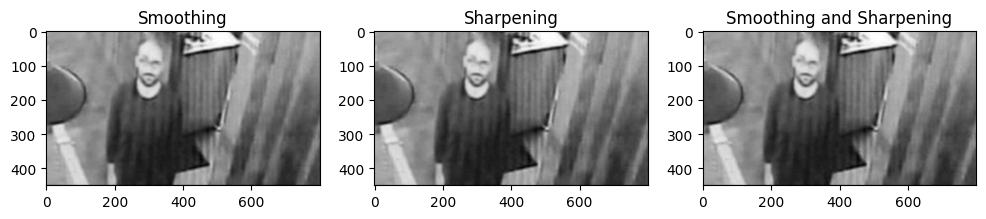

In [75]:
backup_smooth = convolution(backup, kernelSmoothing)
backup_sharp = convolution(backup, kernelSharpening)
backup_smoothNsharp = backup_smooth + backup_sharp

plt.figure(figsize=(12,8))
plt.subplot(1,3,1)
plt.title("Smoothing")
plt.imshow(backup_smooth, cmap='gray')
plt.subplot(1,3,2)
plt.title("Sharpening")
plt.imshow(backup_sharp, cmap='gray')
plt.subplot(1,3,3)
plt.title("Smoothing and Sharpening")
plt.imshow(backup_smoothNsharp, cmap='gray')

In [17]:
def edge_detection(img, kernelx, kernely):
    # Konvolusi sumbu x dan y
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)
    
    # Gabung gradien absolut agar tidak ada nilai negatif
    canvas = np.abs(gx) + np.abs(gy)
    
    # Normalisasi ke rentang 0-255
    if np.max(canvas) != 0:
        canvas = (canvas * 255.0) / np.max(canvas)
    
    # Batas nilai (clip) dan konversi ke uint8
    return np.clip(canvas, 0, 255).astype(np.uint8)

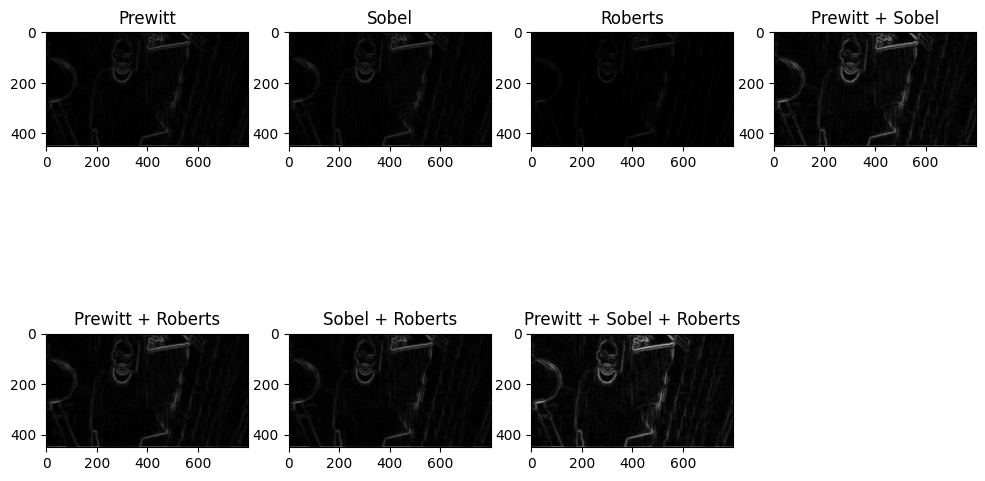

In [28]:
smooth_sharp_prewitt = edge_detection(backup_smoothNsharp, prewittx, prewitty)
smooth_sharp_sobel = edge_detection(backup_smoothNsharp, sobelx, sobely)
smooth_sharp_roberts = edge_detection(backup_smoothNsharp, robertsx, robertsy)
presob = smooth_sharp_prewitt + smooth_sharp_sobel
prerob = smooth_sharp_prewitt + smooth_sharp_roberts
sobrob = smooth_sharp_sobel + smooth_sharp_roberts
presobrob = smooth_sharp_prewitt + smooth_sharp_sobel + smooth_sharp_roberts

plt.figure(figsize=(12,15))
plt.subplot(4,4,1)
plt.title("Prewitt")
plt.imshow(smooth_sharp_prewitt, cmap='gray')
plt.subplot(4,4,2)
plt.title("Sobel")
plt.imshow(smooth_sharp_sobel, cmap='gray')
plt.subplot(4,4,3)
plt.title("Roberts")
plt.imshow(smooth_sharp_roberts, cmap='gray')

plt.subplot(4,4,4)
plt.title("Prewitt + Sobel")
plt.imshow(presob, cmap='gray')
plt.subplot(4,4,5)
plt.title("Prewitt + Roberts")
plt.imshow(prerob, cmap='gray')
plt.subplot(4,4,6)
plt.title("Sobel + Roberts")
plt.imshow(sobrob, cmap='gray')

plt.subplot(4,4,7)
plt.title("Prewitt + Sobel + Roberts")
plt.imshow(presobrob, cmap='gray')

In [67]:
def thresholding(image, angka):
    h, w = image.shape[:2]
    hasil = np.zeros((h,w), dtype=image.dtype)
    
    for x in range(h):
        for y in range(w):
            if(image[x,y] >= angka):
                hasil[x,y] = 255
            else:
                hasil[x,y] = 0
    return hasil

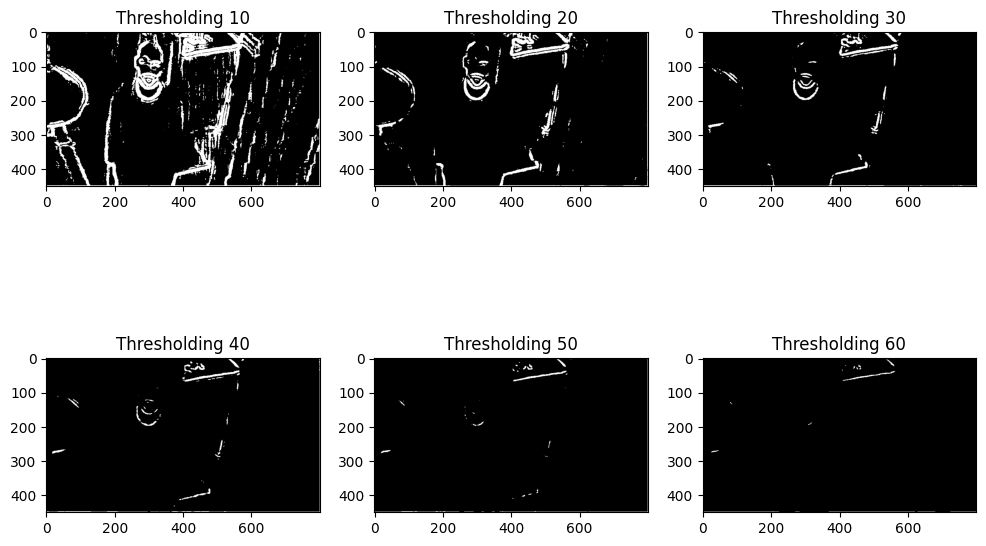

In [68]:
thres10 = thresholding(smooth_sharp_prewitt, 10)
thres20 = thresholding(smooth_sharp_prewitt, 20)
thres30 = thresholding(smooth_sharp_prewitt, 30)
thres40 = thresholding(smooth_sharp_prewitt, 40)
thres50 = thresholding(smooth_sharp_prewitt, 50)
thres60 = thresholding(smooth_sharp_prewitt, 60)

plt.figure(figsize=(12,12))

plt.subplot(3,3,1)
plt.title("Thresholding 10")
plt.imshow(thres10, cmap='gray')
plt.subplot(3,3,2)
plt.title("Thresholding 20")
plt.imshow(thres20, cmap='gray')
plt.subplot(3,3,3)
plt.title("Thresholding 30")
plt.imshow(thres30, cmap='gray')
plt.subplot(3,3,4)
plt.title("Thresholding 40")
plt.imshow(thres40, cmap='gray')
plt.subplot(3,3,5)
plt.title("Thresholding 50")
plt.imshow(thres50, cmap='gray')
plt.subplot(3,3,6)
plt.title("Thresholding 60")
plt.imshow(thres60, cmap='gray')

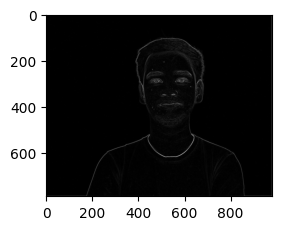

In [83]:
david_edge = edge_detection(david, prewittx, prewitty)

plt.subplot(1,2,1)
plt.imshow(david_edge, cmap='gray')